In [ ]:
!pip install matplotlib numpy scipy

In [2]:
%load_ext autoreload
%autoreload 2

from scipy.constants import speed_of_light as SPEED_OF_LIGHT
import numpy as np
import importlib
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
from copy import copy
import sys
import os
import pickle

from simulation import *

# importlib.reload(simulation)

np.set_printoptions(threshold=sys.maxsize)

In [3]:
base_seed = 1234
batches = 10
realizations = 100

bs_setup = "mmWave"
scenarios = list(SCENARIOS[bs_setup].keys())
scenarios.remove("LOW_UE_HIGH_TARGET")
scenarios.remove("HIGH_UE_LOW_TARGET")

dl_prbs = SCENARIOS[bs_setup][scenarios[0]]["N_PRBS"] - SCENARIOS[bs_setup][scenarios[0]]["UPLINK_PRBS"]
sensing_portions = np.arange(0, dl_prbs+1)/dl_prbs
sensor_densities = SCENARIOS[bs_setup][scenarios[0]]["SENSOR_DENSITIES"]

In [4]:
metric_values = {
    metric: {
        (s,d): None
        for s in scenarios
        for d in sensor_densities
    }
    for metric in [
        "vehicle_position_error",
        "vehicle_sensing_snr",
        "max_sensor_demand",
        "mean_sensor_throughput",
        "mean_target_position_estimation_error",
        "median_target_position_error",
        "full_res_sens_portion"
    ]
}

for b in range(batches):
    np.random.seed(base_seed + b)

    for s in scenarios:
        data = copy(SCENARIOS[bs_setup][s])
        data["REALIZATIONS"] = realizations
        data = pos_vehicles(data, no_warning=True)
        for d in sensor_densities:
            data["SENSOR_DENSITY"] = d
            dl_prbs = data["N_PRBS"] - data["UPLINK_PRBS"]
            sensing_portions = np.arange(0, dl_prbs+1)/dl_prbs
            
            data = pos_sensors(data, no_warning=True)
            data = run_pre_allocation_and_assignment(data)
            data = run_angle_interference_derivations(data)
            data = alloc_beams(data)
            data = run_beam_allocation_interference_derivations(data)
            data = alloc_bandwidth(data, method="orthogonal_split_equal", sens_portions=sensing_portions)
            data = run_pre_assignment(data)
            data = assign_sensors(data)
            data = run_post_assignment(data)

            for metric in metric_values.keys():
                if metric_values[metric][s,d] is None:
                    metric_values[metric][s,d] = np.array([]).reshape(0, len(sensing_portions))

                if metric == "max_sensor_demand":
                    values = data["sensor_demand"]
                    values = np.max(values, axis=(0,1)) # [alloc_decision]
                    metric_values[metric][s,d] = np.vstack([metric_values[metric][s,d], values[np.newaxis, :]]) # [batch, alloc_decision]
                elif metric == "full_res_sens_portion":
                    values = data["unresolved_vehicles_rate"] # [realization, alloc_decision]
                    values = np.sum(values, axis = 0) # [alloc_decision]
                    metric_values[metric][s,d] = np.vstack([metric_values[metric][s,d], values[np.newaxis, :]]) # [batch, alloc_decision]
                    continue
                elif metric == "mean_sensor_throughput":
                    values = data["sensor_comm_thr"]
                    values = np.mean(values, axis=(0,1)) # [realization, alloc_decision]
                    metric_values[metric][s,d] = np.vstack([metric_values[metric][s,d], values[np.newaxis, :]]) # [batch, alloc_decision]
                elif metric == "median_target_position_error":
                    values = data["vehicle_position_error"]
                    values = np.median(values, axis=(0,1)) # [alloc_decision]
                    metric_values[metric][s,d] = np.vstack([metric_values[metric][s,d], values[np.newaxis, :]]) # [batch, alloc_decision]
                else:
                    values = data[metric]
                    if "snr" in metric:
                        values = lin2db(values)
                    if len(values.shape) == 2: # [realization, alloc_decision]
                        mean_value_per_alloc_decision = np.mean(values, axis= 0) # [alloc_decision]
                    elif len(values.shape) == 3: # [realization, vehicle, alloc_decision]
                        mean_value_per_alloc_decision = np.mean( # [alloc_decision]
                            values, # [realization, vehicle, alloc_decision]
                            axis=(0,1), # Average over realizations and vehicles if alloc_decision is present, otherwise just realizations
                            where=data["target_mask"][..., np.newaxis] # [realization, vehicle, alloc_decision]
                        )
                    metric_values[metric][s,d] = np.vstack([metric_values[metric][s,d], mean_value_per_alloc_decision[np.newaxis, :]]) # [batch, alloc_decision]


for s in scenarios:
    for d in sensor_densities:
        for metric in metric_values.keys():
            if metric == "full_res_sens_portion":
                sum_unresolved_vehicles = np.sum(metric_values[metric][s,d], axis=0)
                idxs = np.where(sum_unresolved_vehicles == 0)[0]# [alloc_decision]
                metric_values[metric][s,d] = idxs[0]
            else:
                metric_values[metric][s,d] = np.mean(metric_values[metric][s,d], axis=0) # [alloc_decision]
                

In [5]:
# Save metric_values
os.makedirs("results", exist_ok=True)
with open("results/1_sensing_performance_metric_values.pkl", "wb") as f:
    pickle.dump(metric_values, f)

In [6]:
# Read metric_values
with open("results/1_sensing_performance_metric_values.pkl", "rb") as f:
    metric_values = pickle.load(f)

In [7]:
scenario_labels = {
    s: (f"{(SCENARIOS[bs_setup][s]['TARGET_DENSITY'])*1e6:.0f}T,"
        + f"{SCENARIOS[bs_setup][s]['UE_DENSITY']*1e6:.0f}U/km$^2$"
    )
    for s in scenarios
}

for s in scenario_labels.keys():
    print(f"Scenario: {scenario_labels[s]}")
    for d in sensor_densities:
        snr_value = np.nanmax(metric_values["vehicle_sensing_snr"][s, d])
        pos_error = np.nanmin(metric_values["mean_target_position_estimation_error"][s, d])
        max_sensor_demand = np.nanmax(metric_values["max_sensor_demand"][s, d])
        mean_sensor_throughput = np.nanmean(metric_values["mean_sensor_throughput"][s, d])
        mean_median_target_position_error = np.nanmean(metric_values["median_target_position_error"][s, d])
        print(
            f"  At {d*1e6:.0f} sensors/km² -" +
            f" Mean SNR: {snr_value:.2f} dB," +
            f" Best Pos. Error: {pos_error:.2f} m," +
            f" Max Sensor Demand: {max_sensor_demand/1e6:.2f} Mbps,"+
            f" Mean Sensor Thr: {mean_sensor_throughput/1e6:.2f} Mbps,"+
            f" Mean Median Pos. Error: {mean_median_target_position_error:.2f} m,"+
            f" Full res. at portion: {sensing_portions[metric_values['full_res_sens_portion'][s,d]]*100:.2f}%"
        )

Scenario: 150T,50U/km$^2$
  At 5 sensors/km² - Mean SNR: 37.07 dB, Best Pos. Error: 0.62 m, Max Sensor Demand: 3.62 Mbps, Mean Sensor Thr: 8.35 Mbps, Mean Median Pos. Error: 9.70 m, Full res. at portion: 4.88%
  At 15 sensors/km² - Mean SNR: 45.16 dB, Best Pos. Error: 0.08 m, Max Sensor Demand: 2.88 Mbps, Mean Sensor Thr: 9.37 Mbps, Mean Median Pos. Error: 9.57 m, Full res. at portion: 4.88%
Scenario: 300T,150U/km$^2$
  At 5 sensors/km² - Mean SNR: 34.05 dB, Best Pos. Error: 0.81 m, Max Sensor Demand: 7.50 Mbps, Mean Sensor Thr: 8.53 Mbps, Mean Median Pos. Error: 9.68 m, Full res. at portion: 7.32%
  At 15 sensors/km² - Mean SNR: 41.78 dB, Best Pos. Error: 0.11 m, Max Sensor Demand: 6.48 Mbps, Mean Sensor Thr: 9.85 Mbps, Mean Median Pos. Error: 9.57 m, Full res. at portion: 7.32%


/tmp/ipykernel_3523/1624492178.py:151: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


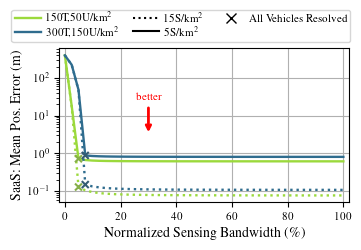

In [8]:
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": 10,

    # IEEE-like sizing
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    # Better PDF output
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

metric_labels = {
    "mean_target_position_estimation_error": "SaaS: Mean Pos. Error (m)",
}

colors = list(reversed(plt.cm.viridis(np.linspace(0.35, 0.85, len(scenario_labels)))))

fig, ax = plt.subplots(
    figsize=(3.5, 2),
    constrained_layout=True
)

metric = "mean_target_position_estimation_error"

for s_idx, s in enumerate(scenario_labels.keys()):
    for density_idx, sensor_density in enumerate(sensor_densities):

        values = metric_values[metric][s, sensor_density]

        label = scenario_labels[s]

        ax.plot(
            sensing_portions * 100,
            values,
            label=label if density_idx == 0 else None,
            linestyle="-" if density_idx == 0 else ":",
            color=colors[s_idx],
            linewidth=1.7
        )

REQ_POSITION_ERROR = SCENARIOS[bs_setup][scenarios[0]]["REQ_POSITION_ERROR"]

# Scattering the point where we start to resolve all vehicles

y = np.array([
    metric_values["mean_target_position_estimation_error"][s,d][metric_values["full_res_sens_portion"][s,d]]
    for d in sensor_densities
    for s in scenario_labels
])

x = sensing_portions[np.array([
    metric_values["full_res_sens_portion"][s,d]
    for d in sensor_densities
    for s in scenario_labels
])]

scatter_colors = []
for c in colors:
    hsv = rgb_to_hsv(c[:3])  # ignore alpha
    hsv[1] *= 0.8 # change saturation
    hsv[2] *= 0.8 # change brightness
    rgb = hsv_to_rgb(hsv)
    scatter_colors.append(np.append(rgb, c[3]))  # restore alpha
scatter_colors = np.array(scatter_colors)

ax.scatter(
    x=x*100,
    y=y,
    color=list(scatter_colors)*2,
    marker="x",
    s=25,
    zorder=10

)

ax.set_ylabel(metric_labels[metric])
ax.set_xlabel(r"Normalized Sensing Bandwidth (\%)")
ax.set_xlim(-2, 102)
ax.set_xticks(np.linspace(0, 100, 6, endpoint=True))
ax.set_yscale('log')
ax.grid()

handles, labels = ax.get_legend_handles_labels()
resolved_vehicles_handle = [Line2D(
    [0], [0],
    color="black",
    marker="x",
    linestyle="None",
    markersize=7,
    label=f"{sensor_densities[1]*1e6:.0f} sensors/km$^2$"
)]
resolved_vehicles_label = ["All Vehicles Resolved"]
sensor_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=":",
        label=f"{sensor_densities[1]*1e6:.0f} sensors/km$^2$"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        label=f"{sensor_densities[0]*1e6:.0f} sensors/km$^2$"
    ),
]

sensor_labels = [
    f"{sensor_densities[1]*1e6:.0f}S/km$^2$",
    f"{sensor_densities[0]*1e6:.0f}S/km$^2$",
]


fig.legend(
    handles=handles[:2] + sensor_handles + resolved_vehicles_handle,
    labels=labels[:2] + sensor_labels + resolved_vehicles_label,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.00, 1.20, 1, 0),
    mode="expand",
    labelspacing=0.3,
    borderpad=0.3,
    handlelength=2.4,
    handletextpad=0.4,
)


ax.annotate(
    "better",
    xy=(30, ax.get_ylim()[1] * 0.005),      # arrow tip (top)
    xytext=(30, ax.get_ylim()[1] * 0.05),  # text below
    arrowprops=dict(
        arrowstyle="->",
        lw=2,
        color="red",
    ),
    ha="center",
    va="center",
    fontsize=8,
    color="red"
)

os.makedirs("figures", exist_ok=True)
fig.savefig("figures/1_sensing_performance.pdf", bbox_inches='tight')
fig.show()